**Multiple Linear Regression on Weather in Szeged 2006-2016 Dataset**  

**Importing Libraries**

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy.stats import yeojohnson
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
df = pd.read_csv("weatherHistory.csv")

**Data Preprocessing**

In [3]:
# first 5 records
df.head() 

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [4]:
# dimension of the dataset
df.shape

(96453, 12)

The dataset initially consists of 96,453 records and 12 different features.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  object 
 1   Summary                   96453 non-null  object 
 2   Precip Type               95936 non-null  object 
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  float64
 8   Visibility (km)           96453 non-null  float64
 9   Loud Cover                96453 non-null  float64
 10  Pressure (millibars)      96453 non-null  float64
 11  Daily Summary             96453 non-null  object 
dtypes: float64(8), object(4)
memory usage: 8.8+ MB


There are 4 categorical variables(with object datatype) and 8 numerical values.

In [6]:
# Checking for duplicates
df.duplicated().sum()

24

There are 24 duplicate records, so dropping them.

In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df.shape

(96429, 12)

After deleting the duplicates, the rows have reduced to 96429.

In [9]:
# checking for missing values
df.isnull().sum()

Formatted Date                0
Summary                       0
Precip Type                 517
Temperature (C)               0
Apparent Temperature (C)      0
Humidity                      0
Wind Speed (km/h)             0
Wind Bearing (degrees)        0
Visibility (km)               0
Loud Cover                    0
Pressure (millibars)          0
Daily Summary                 0
dtype: int64

Precipitation type have 517 rows as null. Since, Precipitation type is a categorical varaible, therefore, we can't impute it, hence, those records need to be dropped.

In [10]:
df.dropna(inplace=True)

In [11]:
df.shape

(95912, 12)

After dropping the null value rows, the rows have now reduced to 95912.

In [12]:
df['Loud Cover'].value_counts()

Loud Cover
0.0    95912
Name: count, dtype: int64

Since, the Loud cover column also has all zeros, it can also be dropped along with the formatted date column and daily summary  as well.

In [13]:
df.drop(columns=['Formatted Date','Loud Cover','Daily Summary'],inplace=True)

In [14]:
df.shape

(95912, 9)

In [15]:
df.head()

,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Pressure (millibars)
0,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,1015.13
1,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,1015.63
2,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,1015.94
3,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,1016.41
4,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,1016.51


Hence, the further analyis will be done on 95912 rows and 9 features.

**Exploring Categorical Variables**

In [16]:
df['Summary'].nunique()

27

In [17]:
df['Precip Type'].nunique()

2

Enconding the categorical variables

In [18]:
df['SummaryEncoded'] = df['Summary'].astype('category').cat.codes
df['PrecipTypeEncoded'] = df['Precip Type'].astype('category').cat.codes
df_copy = df # a copy of the dataframe that consists both original and encoded columns
df_copy.head()

,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Pressure (millibars),SummaryEncoded,PrecipTypeEncoded
0,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,1015.13,19,0
1,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,1015.63,19,0
2,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,1015.94,17,0
3,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,1016.41,19,0
4,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,1016.51,17,0


In [19]:
df.drop(columns=['Summary','Precip Type'],inplace=True) # dropping the original categorical columns now

In [20]:
df.head()

,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Pressure (millibars),SummaryEncoded,PrecipTypeEncoded
0,9.472222,7.388889,0.89,14.1197,251.0,15.8263,1015.13,19,0
1,9.355556,7.227778,0.86,14.2646,259.0,15.8263,1015.63,19,0
2,9.377778,9.377778,0.89,3.9284,204.0,14.9569,1015.94,17,0
3,8.288889,5.944444,0.83,14.1036,269.0,15.8263,1016.41,19,0
4,8.755556,6.977778,0.83,11.0446,259.0,15.8263,1016.51,17,0


**Building the Model**

In [21]:
# predictor variables
X = df[['Temperature (C)','Humidity','Wind Speed (km/h)','Visibility (km)','Pressure (millibars)','PrecipTypeEncoded','SummaryEncoded']]

#Target/response variable
y = df['Apparent Temperature (C)'] 

In [22]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [23]:
# Add a constant to the predictors (intercept)
X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)

# Fit the multiple linear regression model
model = sm.OLS(y_train, X_train).fit()

residuals = model.resid

In [24]:
# Print the summary of the model
print(model.summary())

                               OLS Regression Results                               
Dep. Variable:     Apparent Temperature (C)   R-squared:                       0.990
Model:                                  OLS   Adj. R-squared:                  0.990
Method:                       Least Squares   F-statistic:                 1.082e+06
Date:                      Sun, 19 May 2024   Prob (F-statistic):               0.00
Time:                              09:39:33   Log-Likelihood:            -1.1422e+05
No. Observations:                     76729   AIC:                         2.285e+05
Df Residuals:                         76721   BIC:                         2.285e+05
Df Model:                                 7                                         
Covariance Type:                  nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------

**Checking the Assumptions of Multiple Linear Regression**

1. Linearity: The relationship between response and predictor variables should be linear.

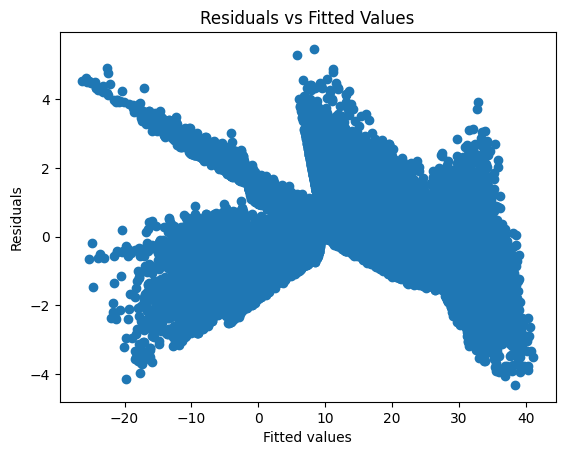

In [25]:
# Plot residuals vs. fitted values
plt.scatter(model.fittedvalues, residuals)
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')
plt.show()

Since, no specific pattern can be found, hence linearity is present.

2. Independence: The residuals (errors) should be independent of each other.

In [26]:
dw_test = sm.stats.durbin_watson(model.resid)
print(f"Durbin-Watson test statistic: {dw_test}")

Durbin-Watson test statistic: 2.0023741664480403


No autocorrelation as the test statistic value is almost 2.

3. Homoscedasticity:The variance of the residuals should be constant across all levels of the predictors.

H0: The residuals have constant variance (homoscedasticity).<br/>
H1: The residuals do not have constant variance (heteroscedasticity).

In [27]:
# Check for homoscedasticity using the Breusch-Pagan test

bp_test = het_breuschpagan(model.resid, model.model.exog)
print(f"Breusch-Pagan test p-value: {bp_test[1]}")

Breusch-Pagan test p-value: 0.0


Since, p-value< 0.05, hence H0 is rejected indicating no homoscedasticity.

4. Normality of Residuals: The residuals should follow a normal distribution.

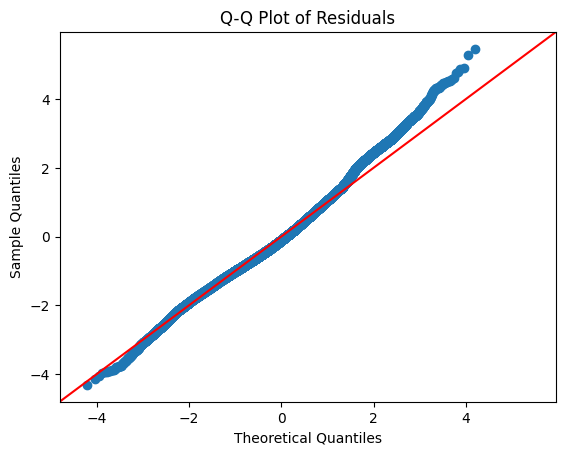

In [28]:
sm.qqplot(model.resid, line='45')
plt.title('Q-Q Plot of Residuals')
plt.show()

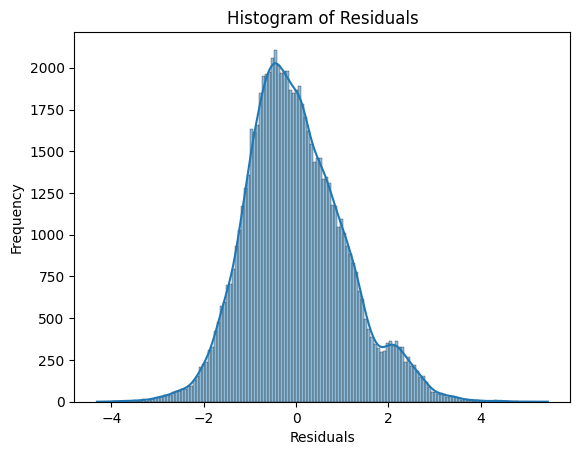

In [29]:
sns.histplot(residuals,kde=True)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Histogram of Residuals')
plt.show()

Errors are not completely normal, but do have a certain extent of normality.

5. No or Little Multicollinearity.

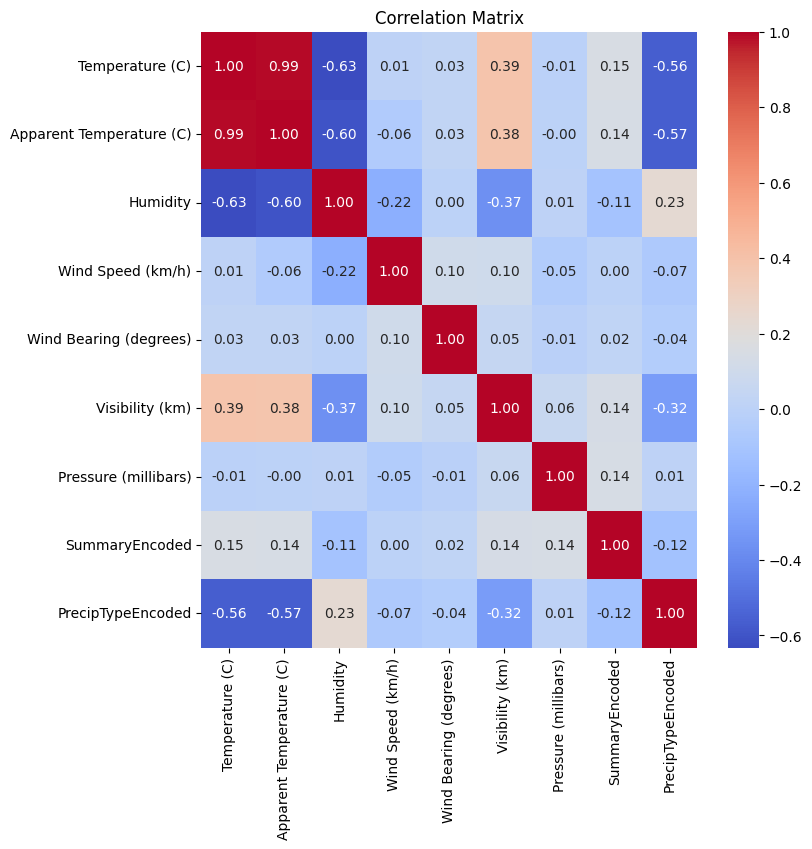

In [30]:
correlation_matrix = df.corr()
plt.figure(figsize=(8, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [31]:
vif_data = pd.DataFrame()
vif_data["feature"] = X_train.columns
vif_data["VIF"] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
print("\nVariance Inflation Factor (VIF):")
print(vif_data)


Variance Inflation Factor (VIF):
                feature         VIF
0                 const  148.214277
1       Temperature (C)    2.559108
2              Humidity    1.977646
3     Wind Speed (km/h)    1.113859
4       Visibility (km)    1.269750
5  Pressure (millibars)    1.029003
6     PrecipTypeEncoded    1.590143
7        SummaryEncoded    1.052548


Since, the VIFs' are all around 1, this indicates very minimal multicollinearity b/w the variables.<br/>
Only Temperature has multicollinearity with Apparent Temperature

**Model Adequacy**

In [32]:
# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Calculate R-squared and Adjusted R-squared
r_squared = model.rsquared
adjusted_r_squared = model.rsquared_adj
print("R-squared:", r_squared)
print("Adjusted R-squared:", adjusted_r_squared)
print()
# Calculate MSE, RMSE, and MAE for training data
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
mae_train = mean_absolute_error(y_train, y_train_pred)

print("Training Data Metrics:")
print("Mean Squared Error (MSE):", mse_train)
print("Root Mean Squared Error (RMSE):", rmse_train)
print("Mean Absolute Error (MAE):", mae_train)

# Calculate MSE, RMSE, and MAE for testing data
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
mae_test = mean_absolute_error(y_test, y_test_pred)
print()
print("Testing Data Metrics:")
print("Mean Squared Error (MSE):", mse_test)
print("Root Mean Squared Error (RMSE):", rmse_test)
print("Mean Absolute Error (MAE):", mae_test)


R-squared: 0.9899727347693801
Adjusted R-squared: 0.9899718198848424

Training Data Metrics:
Mean Squared Error (MSE): 1.149629080279635
Root Mean Squared Error (RMSE): 1.0722075733176086
Mean Absolute Error (MAE): 0.8443332895557464

Testing Data Metrics:
Mean Squared Error (MSE): 1.165896846739797
Root Mean Squared Error (RMSE): 1.079767033549273
Mean Absolute Error (MAE): 0.848053312582451


**The Multiple Linear Regression Model thus formed is moderately accurate.**